# Fit Neural-Network Intensities And Solve With `jact`

This notebook demonstrates the workflow described in the README: fit flexible intensity models first, then pass the fitted callables straight into `jact` for probability computation.

The example stays synthetic and CPU-friendly:

1. define an illness-death `StateSpace`
2. generate smooth hazard targets on an attained-age and duration grid
3. fit three small neural networks in pure `jax`
4. wrap the learned parameters as `jact` intensity callables
5. call `model.solve(...)` directly on the fitted model
            


In [1]:
import jact
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
            


## State space and synthetic hazards

We use the same three-state illness-death topology as the main example notebook:

- `healthy -> disabled`
- `healthy -> dead`
- `disabled -> dead`

The hazard functions below play the role of a stand-in estimation target. In a real workflow they would be replaced by your fitted model outputs.
            


In [2]:
state_space = jact.StateSpace(
    states=["healthy", "disabled", "dead"],
    transitions=[
        ("healthy", "disabled"),
        ("healthy", "dead"),
        ("disabled", "dead"),
    ],
)


def true_disability_onset(attained_age, duration):
    return 0.015 + 0.0012 * (attained_age - 45.0) + 0.02 * jnp.exp(-duration / 3.0)


def true_mortality_healthy(attained_age, duration):
    return 0.004 + 0.0006 * (attained_age - 45.0) + jnp.zeros_like(duration)


def true_mortality_disabled(attained_age, duration):
    return 0.012 + 0.0010 * (attained_age - 45.0) + 0.012 * (1.0 - jnp.exp(-duration / 2.5))


print(state_space)
            


StateSpace(states=['healthy', 'disabled', 'dead'], transitions=[disabled->dead, healthy->dead, healthy->disabled])


## Synthetic training targets

To keep the notebook focused on the handoff into `jact`, we train against synthetic hazard targets on a regular grid of attained age and current-state duration. That is still the same interface boundary as a real fitted model: the end product is a callable `lambda(t, d, **kwargs) -> hazard`.
            


In [3]:
AGE_CENTER = 60.0
AGE_SCALE = 12.0
DURATION_SCALE = 10.0
HIDDEN_WIDTH = 32
TRAIN_STEPS = 1200
LEARNING_RATE = 0.005


def make_regression_grid(hazard_fn):
    ages = jnp.linspace(40.0, 85.0, 80)
    durations = jnp.linspace(0.0, 15.0, 80)
    age_grid, duration_grid = jnp.meshgrid(ages, durations, indexing="ij")
    targets = hazard_fn(age_grid, duration_grid)
    features = jnp.stack(
        [
            (age_grid.reshape(-1) - AGE_CENTER) / AGE_SCALE,
            duration_grid.reshape(-1) / DURATION_SCALE,
        ],
        axis=1,
    )
    return {
        "ages": ages,
        "durations": durations,
        "features": features,
        "targets": targets.reshape(-1),
    }


datasets = {
    "healthy -> disabled": make_regression_grid(true_disability_onset),
    "healthy -> dead": make_regression_grid(true_mortality_healthy),
    "disabled -> dead": make_regression_grid(true_mortality_disabled),
}

for name, dataset in datasets.items():
    print(name, dataset["features"].shape, dataset["targets"].shape)
            


healthy -> disabled (6400, 2) (6400,)
healthy -> dead (6400, 2) (6400,)
disabled -> dead (6400, 2) (6400,)


## Pure JAX neural networks

Each transition gets its own small multilayer perceptron. The output passes through `softplus` so the learned intensity stays non-negative.
            


In [4]:
def init_params(key, hidden_width=HIDDEN_WIDTH):
    k1, k2, k3 = jax.random.split(key, 3)
    return {
        "w1": 0.4 * jax.random.normal(k1, (2, hidden_width)),
        "b1": jnp.zeros((hidden_width,)),
        "w2": 0.4 * jax.random.normal(k2, (hidden_width, hidden_width)),
        "b2": jnp.zeros((hidden_width,)),
        "w3": 0.4 * jax.random.normal(k3, (hidden_width, 1)),
        "b3": jnp.zeros((1,)),
    }


def forward(params, features):
    hidden_1 = jnp.tanh(features @ params["w1"] + params["b1"])
    hidden_2 = jnp.tanh(hidden_1 @ params["w2"] + params["b2"])
    raw_output = hidden_2 @ params["w3"] + params["b3"]
    return jax.nn.softplus(raw_output[..., 0])


def mse_loss(params, features, targets):
    prediction = forward(params, features)
    return jnp.mean((prediction - targets) ** 2)


@jax.jit
def train_step(params, opt_state, features, targets):
    loss, grads = jax.value_and_grad(mse_loss)(params, features, targets)

    step, first_moment, second_moment = opt_state
    step = step + 1
    beta1 = 0.9
    beta2 = 0.999
    eps = 1e-8

    first_moment = jax.tree.map(
        lambda m, g: beta1 * m + (1.0 - beta1) * g,
        first_moment,
        grads,
    )
    second_moment = jax.tree.map(
        lambda v, g: beta2 * v + (1.0 - beta2) * (g * g),
        second_moment,
        grads,
    )

    step_f = step.astype(jnp.float32)
    first_hat = jax.tree.map(lambda m: m / (1.0 - beta1**step_f), first_moment)
    second_hat = jax.tree.map(lambda v: v / (1.0 - beta2**step_f), second_moment)

    params = jax.tree.map(
        lambda p, m, v: p - LEARNING_RATE * m / (jnp.sqrt(v) + eps),
        params,
        first_hat,
        second_hat,
    )

    return params, (step, first_moment, second_moment), loss


def fit_transition_model(key, dataset, steps=TRAIN_STEPS):
    params = init_params(key)
    zeros = jax.tree.map(jnp.zeros_like, params)
    opt_state = (jnp.array(0, dtype=jnp.int32), zeros, zeros)
    history = []

    for _ in range(steps):
        params, opt_state, loss = train_step(
            params,
            opt_state,
            dataset["features"],
            dataset["targets"],
        )
        history.append(loss)

    prediction = forward(params, dataset["features"])
    rmse = jnp.sqrt(jnp.mean((prediction - dataset["targets"]) ** 2))
    return params, jnp.array(history), rmse
            


In [5]:
master_key = jax.random.key(0)
keys = jax.random.split(master_key, 3)

fitted = {}
for key, (name, dataset) in zip(keys, datasets.items()):
    params, history, rmse = fit_transition_model(key, dataset)
    fitted[name] = {
        "params": params,
        "history": history,
        "rmse": rmse,
    }
    print(
        f"{name}: loss {float(history[0]):.6f} -> {float(history[-1]):.6f}, "
        f"rmse = {float(rmse):.6f}"
    )
            


healthy -> disabled: loss 0.085408 -> 0.000001, rmse = 0.000903
healthy -> dead: loss 0.675345 -> 0.000066, rmse = 0.008123
disabled -> dead: loss 6.638354 -> 0.000120, rmse = 0.010927


## Compare learned hazards to the target surface

We inspect the training loss and one attained-age slice. The fit does not need to be perfect for `jact`; it only needs to produce a JAX-compatible callable with the right hazard semantics.
            


<ipython-input-1-5400e51db4d1>:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


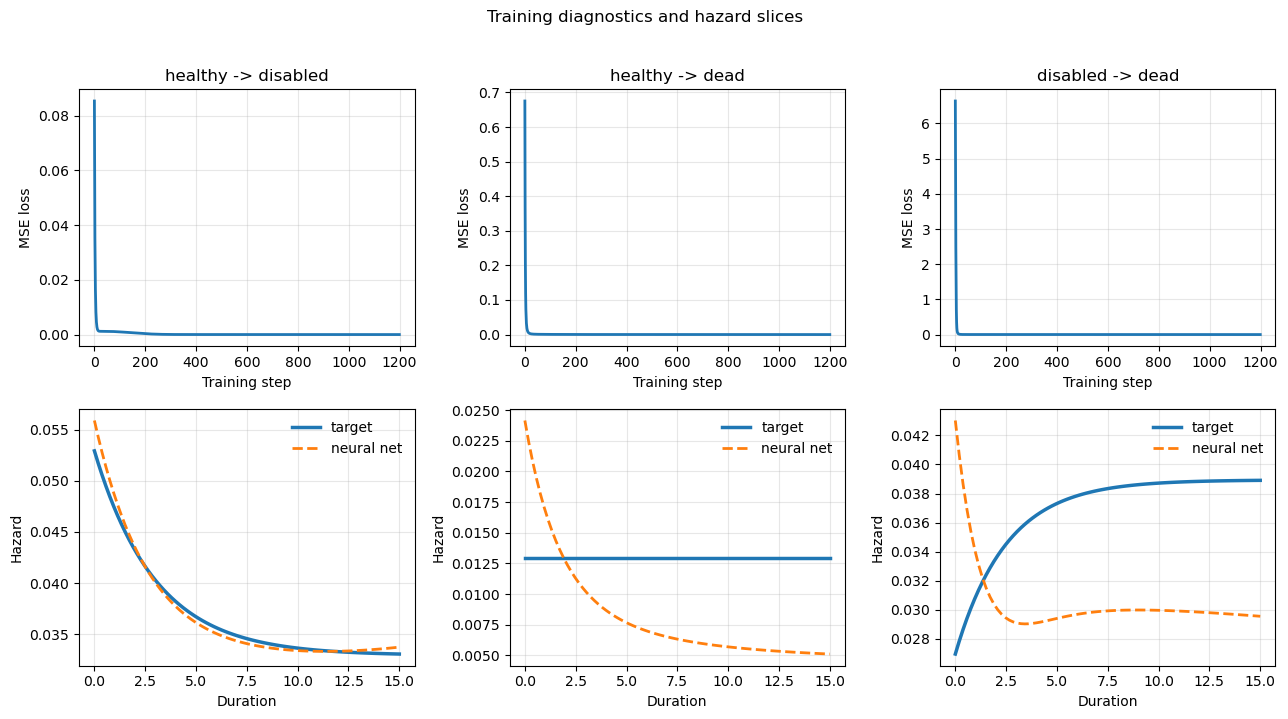

In [6]:
def evaluate_fitted_surface(params, ages, durations):
    age_grid, duration_grid = jnp.meshgrid(ages, durations, indexing="ij")
    features = jnp.stack(
        [
            (age_grid.reshape(-1) - AGE_CENTER) / AGE_SCALE,
            duration_grid.reshape(-1) / DURATION_SCALE,
        ],
        axis=1,
    )
    return forward(params, features).reshape(age_grid.shape)


fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_age_index = 35

hazard_fns = {
    "healthy -> disabled": true_disability_onset,
    "healthy -> dead": true_mortality_healthy,
    "disabled -> dead": true_mortality_disabled,
}

for col, (name, dataset) in enumerate(datasets.items()):
    history = fitted[name]["history"]
    axes[0, col].plot(history, linewidth=2.0)
    axes[0, col].set_title(name)
    axes[0, col].set_xlabel("Training step")
    axes[0, col].set_ylabel("MSE loss")
    axes[0, col].grid(alpha=0.3)

    fitted_surface = evaluate_fitted_surface(
        fitted[name]["params"],
        dataset["ages"],
        dataset["durations"],
    )
    true_slice = hazard_fns[name](dataset["ages"][plot_age_index], dataset["durations"])
    fitted_slice = fitted_surface[plot_age_index]

    axes[1, col].plot(dataset["durations"], true_slice, linewidth=2.5, label="target")
    axes[1, col].plot(
        dataset["durations"],
        fitted_slice,
        linewidth=2.0,
        linestyle="--",
        label="neural net",
    )
    axes[1, col].set_xlabel("Duration")
    axes[1, col].set_ylabel("Hazard")
    axes[1, col].grid(alpha=0.3)
    axes[1, col].legend(frameon=False)

fig.suptitle("Training diagnostics and hazard slices", y=1.02)
fig.tight_layout()
plt.show()
            


## Turn fitted parameters into solver callables

This is the key integration step. `jact` does not need to know how the neural network was trained. It only needs a callable that accepts solver time `t`, duration grid `d`, and solve-time covariates such as `age`.
            


In [7]:
def neural_intensity(params):
    def intensity(t, d, *, age):
        attained_age = age[:, None] + jnp.zeros_like(d) + t
        duration = jnp.zeros((age.shape[0], 1), dtype=d.dtype) + d
        features = jnp.stack(
            [
                (attained_age - AGE_CENTER) / AGE_SCALE,
                duration / DURATION_SCALE,
            ],
            axis=-1,
        )
        flat_features = features.reshape((-1, 2))
        return forward(params, flat_features).reshape(attained_age.shape)

    return intensity


def true_intensity(hazard_fn):
    def intensity(t, d, *, age):
        attained_age = age[:, None] + jnp.zeros_like(d) + t
        duration = jnp.zeros((age.shape[0], 1), dtype=d.dtype) + d
        return hazard_fn(attained_age, duration)

    return intensity


fitted_model = state_space.build(
    transitions={
        ("healthy", "disabled"): neural_intensity(
            fitted["healthy -> disabled"]["params"]
        ),
        ("healthy", "dead"): neural_intensity(fitted["healthy -> dead"]["params"]),
        ("disabled", "dead"): neural_intensity(
            fitted["disabled -> dead"]["params"]
        ),
    }
)

reference_model = state_space.build(
    transitions={
        ("healthy", "disabled"): true_intensity(true_disability_onset),
        ("healthy", "dead"): true_intensity(true_mortality_healthy),
        ("disabled", "dead"): true_intensity(true_mortality_disabled),
    }
)

print(fitted_model.info("healthy", "disabled"))
            


TransitionInfo(source='healthy', target='disabled', assignment='transitions', callable=<function neural_intensity.<locals>.intensity at 0x7f2e9cef50c0>, index=None)


## Solve probabilities directly from the fitted model

From this point on the workflow is identical to any other `jact` model. We pass a batch of entry ages into `solve(...)` and compare the fitted model against the synthetic ground truth model on the same state space.
            


In [8]:
ages = jnp.array([45.0, 60.0, 75.0], dtype=jnp.float32)

fitted_result = fitted_model.solve(
    initial="healthy",
    horizon=12,
    steps_per_unit=12,
    record_every=12,
    probability=jact.probability.StateProbability(),
    age=ages,
)

reference_result = reference_model.solve(
    initial="healthy",
    horizon=12,
    steps_per_unit=12,
    record_every=12,
    probability=jact.probability.StateProbability(),
    age=ages,
)

print("states =", fitted_result.states)
print("probability shape =", fitted_result.probability.shape)
print(
    "maximum row-sum error =",
    float(jnp.max(jnp.abs(jnp.sum(fitted_result.probability, axis=-1) - 1.0))),
)
print(
    "maximum fitted-vs-reference probability difference =",
    float(jnp.max(jnp.abs(fitted_result.probability - reference_result.probability))),
)
            


states = ('healthy', 'disabled', 'dead')
probability shape = (13, 3, 3)
maximum row-sum error = 1.1920928955078125e-07
maximum fitted-vs-reference probability difference = 0.03515517711639404


<ipython-input-1-3a8835bb22c0>:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


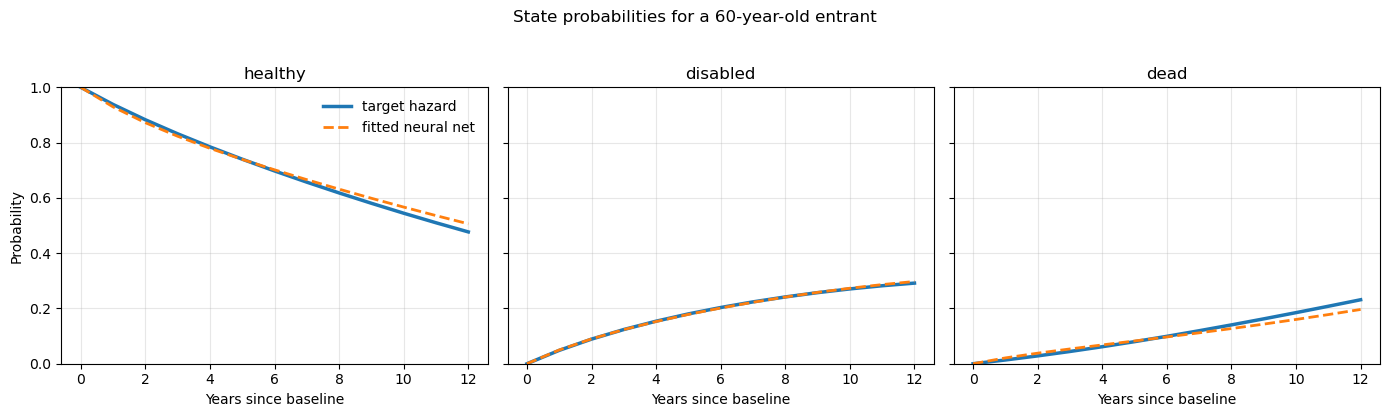

In [9]:
time_years = jnp.arange(fitted_result.probability.shape[0])
representative_index = 1

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for state_index, state_name in enumerate(fitted_result.states):
    axes[state_index].plot(
        time_years,
        reference_result.probability[:, representative_index, state_index],
        linewidth=2.5,
        label="target hazard",
    )
    axes[state_index].plot(
        time_years,
        fitted_result.probability[:, representative_index, state_index],
        linewidth=2.0,
        linestyle="--",
        label="fitted neural net",
    )
    axes[state_index].set_title(state_name)
    axes[state_index].set_xlabel("Years since baseline")
    axes[state_index].set_ylim(0.0, 1.0)
    axes[state_index].grid(alpha=0.3)

axes[0].set_ylabel("Probability")
axes[0].legend(frameon=False)
fig.suptitle("State probabilities for a 60-year-old entrant", y=1.03)
fig.tight_layout()
plt.show()
            


## Notes

- The solver sees the fitted neural networks exactly the same way it sees hand-written parametric hazards: as JAX callables on `(t, d, **kwargs)`.
- Nothing in `state_space.build(...)` or `model.solve(...)` changes when the intensity model comes from fitting.
- The same handoff pattern works for richer estimators too, as long as the final hazard callable remains JIT-compatible.
            
